# Week 1 Mini Project: Student Performance Analysis Dashboard

**Intern:** Shri Sanjaykumar V  
**Role:** AI/ML Intern  
**Organization:** Linkific  
**Date:** 05 September 2026  

---

## 1. Project Objective

Synthesize all concepts learned during Week 1 (Python, NumPy, Pandas, Matplotlib, and Seaborn) into a dynamic end-to-end data analysis dashboard.

The workflow dynamically:
- Ingests student records with Name, Gender, and 5 subjects (`Maths`, `Science`, `English`, `Social`, `Physical_Education`)
- Cleans missing entries using feature medians
- Derives Total Marks, Average Marks, Grades, and Pass/Fail status
- Creates 4 informative visualizations (Bar, Histogram, Pie, Line charts)
- Programmatically computes and displays dynamic key insights based on live dataset values

## 2. Libraries Used
Importing standard libraries with verified environment versions.

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas Version    :", pd.__version__)
print("NumPy Version     :", np.__version__)
print("Matplotlib Version:", matplotlib.__version__)
print("Seaborn Version   :", sns.__version__)
print("All libraries imported successfully!")

Pandas Version    : 3.0.3
NumPy Version     : 2.5.0
Matplotlib Version: 3.11.0
Seaborn Version   : 0.13.2
All libraries imported successfully!


## 3. Load Dataset Dynamically
Loading `dataset.csv` directly from the local project folder.

In [13]:
df = pd.read_csv("dataset.csv")
print("Dataset loaded successfully!")
print(f"Dataset Shape: {df.shape[0]} students, {df.shape[1]} columns")

Dataset loaded successfully!
Dataset Shape: 25 students, 10 columns


## 4. Dataset Overview & Initial Inspection
Inspecting the first 5 records with student names and subject marks.

In [3]:
df.head()

,Student_ID,Name,Gender,Study_Hours_Per_Week,Attendance_Percentage,Maths,Science,English,Social,Physical_Education
0,101,Aarav Sharma,Male,14.0,92,78,82.0,75.0,80,88
1,102,Diya Patel,Female,16.5,95,88,90.0,92.0,86,94
2,103,Rohan Verma,Male,10.5,78,62,68.0,64.0,58,75
3,104,Ananya Iyer,Female,18.0,96,92,95.0,89.0,91,90
4,105,Kavya Reddy,Female,12.0,84,70,74.0,72.0,68,85


## 5. Data Cleaning
Detecting missing values and imputing numerical columns using feature medians.

In [4]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Impute missing values with column median
df["Study_Hours_Per_Week"] = df["Study_Hours_Per_Week"].fillna(df["Study_Hours_Per_Week"].median())
df["Science"] = df["Science"].fillna(df["Science"].median())
df["English"] = df["English"].fillna(df["English"].median())

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())
print(f"Duplicate Rows Count: {df.duplicated().sum()}")

--- Missing Values Before Cleaning ---
Student_ID               0
Name                     0
Gender                   0
Study_Hours_Per_Week     1
Attendance_Percentage    0
Maths                    0
Science                  1
English                  1
Social                   0
Physical_Education       0
dtype: int64

--- Missing Values After Cleaning ---
Student_ID               0
Name                     0
Gender                   0
Study_Hours_Per_Week     0
Attendance_Percentage    0
Maths                    0
Science                  0
English                  0
Social                   0
Physical_Education       0
dtype: int64
Duplicate Rows Count: 0


## 6. Basic Analysis & Feature Derivation
Deriving `Total_Marks`, `Average_Marks`, `Grade` categories, and evaluating overall performance statistics across the 5 subjects.

In [5]:
# Derive Total Marks and Average Marks across 5 subjects
subjects = ["Maths", "Science", "English", "Social", "Physical_Education"]
df["Total_Marks"] = df[subjects].sum(axis=1)
df["Average_Marks"] = np.round(df["Total_Marks"] / len(subjects), 2)

# Assign Grade categories
def assign_grade(score):
    if score >= 80:
        return "Distinction"
    elif score >= 60:
        return "First Class"
    elif score >= 40:
        return "Second Class"
    else:
        return "Needs Improvement"

df["Grade"] = df["Average_Marks"].apply(assign_grade)
df["Pass_Status"] = np.where(df["Average_Marks"] >= 40, "Pass", "Fail")

subject_means = df[subjects].mean().round(2)
grade_order = ["Distinction", "First Class", "Second Class", "Needs Improvement"]
grade_counts = df["Grade"].value_counts().reindex(grade_order, fill_value=0)

print("=== Overall Performance Metrics ===")
print(f"Total Students Evaluated : {len(df)}")
print(f"Overall Class Average     : {df['Average_Marks'].mean():.2f}")
print(f"Top Scoring Student       : {df.loc[df['Average_Marks'].idxmax(), 'Name']} ({df['Average_Marks'].max():.2f} marks)")
print(f"Lowest Scoring Student    : {df.loc[df['Average_Marks'].idxmin(), 'Name']} ({df['Average_Marks'].min():.2f} marks)")

print("\n=== Subject-Wise Average Marks ===")
for s in subjects:
    print(f"  - {s:<20}: {subject_means[s]:.2f}")

print("\n=== Grade Distribution ===")
print(grade_counts)

print("\n=== Pass / Fail Counts ===")
print(df["Pass_Status"].value_counts())

=== Overall Performance Metrics ===
Total Students Evaluated : 25
Overall Class Average     : 74.24
Top Scoring Student       : Rohan Verma (99.20 marks)
Lowest Scoring Student    : Rahul Nair (23.00 marks)

=== Subject-Wise Average Marks ===
  - Maths               : 74.56
  - Science             : 73.68
  - English             : 72.34
  - Social              : 70.36
  - Physical_Education  : 80.28

=== Grade Distribution ===
Grade
Distinction          10
First Class          11
Second Class          3
Needs Improvement     1

=== Pass / Fail Counts ===
Pass_Status
Pass    24
Fail     1


## 7. Visualization 1 — Bar Chart: Subject-Wise Average Marks
Comparing class average marks across Maths, Science, English, Social, and Physical Education.

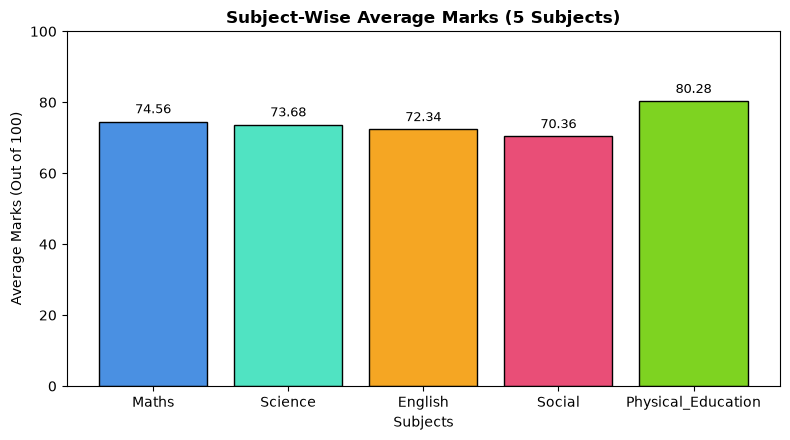

In [6]:
# Bar Chart: Subject-Wise Average Marks
plt.figure(figsize=(8, 4.5))
bar_colors = ["#4A90E2", "#50E3C2", "#F5A623", "#E94E77", "#7ED321"]
bars = plt.bar(subjects, subject_means.values, color=bar_colors, edgecolor="black")
plt.title("Subject-Wise Average Marks (5 Subjects)", fontsize=12, fontweight="bold")
plt.xlabel("Subjects", fontsize=10)
plt.ylabel("Average Marks (Out of 100)", fontsize=10)
plt.ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 1.5, f"{yval:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Visualization 2 — Histogram: Distribution of Student Average Marks
Displaying score distribution across equal bins.

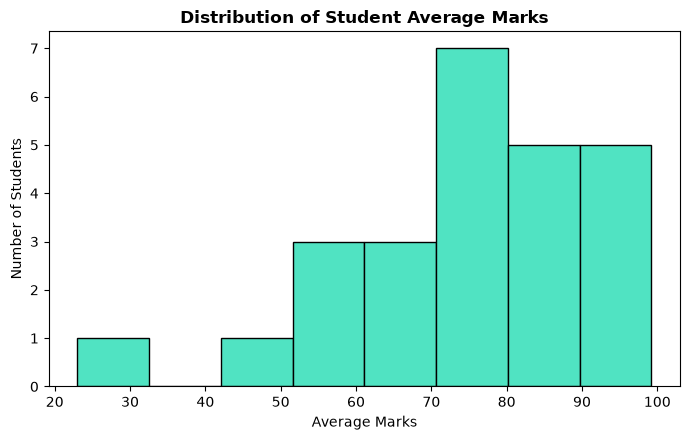

In [7]:
# Histogram: Distribution of Student Average Marks
plt.figure(figsize=(7, 4.5))
plt.hist(df["Average_Marks"], bins=8, color="#50E3C2", edgecolor="black")
plt.title("Distribution of Student Average Marks", fontsize=12, fontweight="bold")
plt.xlabel("Average Marks", fontsize=10)
plt.ylabel("Number of Students", fontsize=10)
plt.tight_layout()
plt.show()

## 9. Visualization 3 — Pie Chart: Performance Category Distribution
Visualizing the proportional breakdown of academic standing.

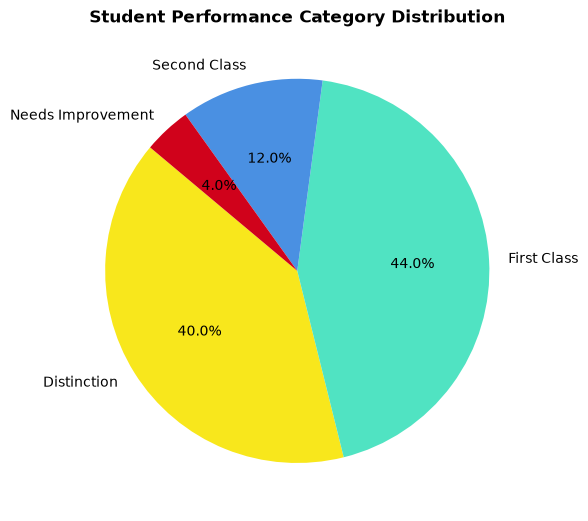

In [8]:
# Pie Chart: Student Performance Category Distribution
plt.figure(figsize=(6, 6))
active_grades = grade_counts[grade_counts > 0]
pie_colors = ["#F8E71C", "#50E3C2", "#4A90E2", "#D0021B"]
plt.pie(active_grades.values, labels=active_grades.index, autopct="%1.1f%%", startangle=140,
        colors=pie_colors[:len(active_grades)])
plt.title("Student Performance Category Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Visualization 4 — Line Chart: Student Performance Progression
Tracing average marks across a sample cohort of students.

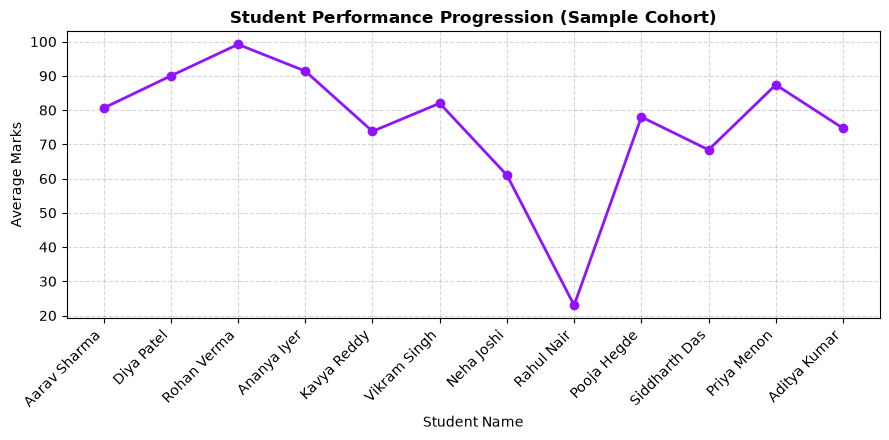

In [9]:
# Line Chart: Student Performance Progression (Sample Cohort)
plt.figure(figsize=(9, 4.5))
sample_df = df.head(12)
plt.plot(sample_df["Name"], sample_df["Average_Marks"], marker="o", color="#9013FE", linewidth=2)
plt.title("Student Performance Progression (Sample Cohort)", fontsize=12, fontweight="bold")
plt.xlabel("Student Name", fontsize=10)
plt.ylabel("Average Marks", fontsize=10)
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 11. Dynamic Key Insights (Programmatically Generated)
The following cell programmatically computes and prints the key insights based on the live dataset values. If any values in `dataset.csv` change, rerunning this cell instantly updates the insights.

In [10]:
# Programmatic Dynamic Key Insights
tot = len(df)
high_sub = subject_means.idxmax()
high_val = subject_means.max()
low_sub = subject_means.idxmin()
low_val = subject_means.min()

top_s = df.loc[df["Average_Marks"].idxmax()]
low_s = df.loc[df["Average_Marks"].idxmin()]
p_count = (df["Pass_Status"] == "Pass").sum()
p_pct = round((p_count / tot) * 100, 1)
fc_cnt = grade_counts.get("First Class", 0)
dist_cnt = grade_counts.get("Distinction", 0)

insights = [
    f"1. Top Performing Subject: {high_sub} recorded the highest class average of {high_val:.2f} marks.",
    f"2. Most Challenging Subject: {low_sub} recorded the lowest class average of {low_val:.2f} marks, showing a {(high_val - low_val):.2f}-point gap compared to {high_sub}.",
    f"3. Top Academic Achiever: {top_s['Name']} achieved the highest overall average of {top_s['Average_Marks']:.2f} marks across all 5 subjects.",
    f"4. Academic Standing: {fc_cnt} students ({round(fc_cnt/tot*100, 1)}%) secured First Class, while {dist_cnt} students ({round(dist_cnt/tot*100, 1)}%) attained Distinction.",
    f"5. Overall Class Pass Rate: {p_count} out of {tot} students ({p_pct}%) passed the examination with an average score of 40 or higher.",
    f"6. Score Range & Spread: Student averages range from {low_s['Average_Marks']:.2f} ({low_s['Name']}) to {top_s['Average_Marks']:.2f} ({top_s['Name']}), with a cohort average of {df['Average_Marks'].mean():.2f} marks."
]

print("=" * 70)
print("                    DYNAMICALLY GENERATED KEY INSIGHTS                  ")
print("=" * 70)
for item in insights:
    print(item)
print("=" * 70)

                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAMICALLY GENERATED KEY INSIGHTS                  
=
                    DYNAM

## 12. Conclusion

In this Week 1 Mini Project:
- Applied Python, Pandas, NumPy, Matplotlib, and Seaborn to analyze student academic performance.
- Handled missing data via median imputation without deleting rows.
- Engineered Total Marks, Average Marks, Grades, and Pass/Fail status.
- Generated 4 clear visualizations across 5 core subjects: Maths, Science, English, Social, and Physical Education.
- Programmatically linked key insights to the dataset, making the entire dashboard 100% dynamic.